# ResNet50 Transfer Learning Baseline
PM25Vision Dataset - Air Quality Classification from Street-Level Imagery

## Overview
This notebook trains a ResNet50 model with transfer learning on the PM25Vision dataset.
- **Strategy**: Freeze pre-trained ImageNet weights, fine-tune only the final layer
- **Training**: 100 epochs with Adam optimizer (lr=0.001)
- **Batch Size**: 32

In [12]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve, auc
)
import json
import time
import os
import warnings
warnings.filterwarnings('ignore')

In [13]:
# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Hyperparameters
CONFIG = {
    'model_name': 'ResNet50',
    'batch_size': 32,
    'learning_rate': 0.001,
    'epochs': 100,
    'image_size': 224
}

print(f"Model: {CONFIG['model_name']}")
print(f"Batch Size: {CONFIG['batch_size']}")
print(f"Learning Rate: {CONFIG['learning_rate']}")
print(f"Epochs: {CONFIG['epochs']}")

Device: cuda
Model: ResNet50
Batch Size: 32
Learning Rate: 0.001
Epochs: 100


In [14]:
# Custom Dataset Class
class PM25Dataset(torch.utils.data.Dataset):
    """Custom dataset loader for PM25Vision dataset."""
    
    def __init__(self, metadata_path, images_dir, transform=None):
        """
        Args:
            metadata_path: Path to metadata CSV file
            images_dir: Directory containing image files
            transform: Torchvision transforms to apply
        """
        self.df = pd.read_csv(metadata_path)
        self.images_dir = images_dir
        self.transform = transform
        
        # Create label encoding
        unique_bins = sorted(self.df['pm25_bin'].unique())
        self.bin_to_label = {bin_name: idx for idx, bin_name in enumerate(unique_bins)}
        self.label_to_bin = {idx: bin_name for bin_name, idx in self.bin_to_label.items()}
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.images_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        label = self.bin_to_label[row['pm25_bin']]
        return image, label

In [15]:
# Data Loading and Preprocessing
import torch
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Loading datasets...")

# Load datasets
train_dataset = datasets.ImageFolder(
    "data/train/samples_by_bin",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    "data/test/samples_by_bin",
    transform=transform
)

# --------------------------------------------------
# FORCE NUMERICALLY SORTED CLASS ORDER (CRITICAL FIX)
# --------------------------------------------------

# Sort classes by numeric lower bound of range
sorted_classes = sorted(
    train_dataset.classes,
    key=lambda x: int(x.split('-')[0])
)

# Apply same class order to BOTH datasets
train_dataset.classes = sorted_classes
train_dataset.class_to_idx = {
    class_name: idx for idx, class_name in enumerate(sorted_classes)
}

test_dataset.classes = sorted_classes
test_dataset.class_to_idx = {
    class_name: idx for idx, class_name in enumerate(sorted_classes)
}

# --------------------------------------------------

num_classes = len(sorted_classes)
class_names = sorted_classes

# DataLoaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=4
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=4
)

print(f"\nDataset Info:")
print(f"  Classes: {class_names}")
print(f"  Num Classes: {num_classes}")
print(f"  Train Samples: {len(train_dataset)}")
print(f"  Test Samples: {len(test_dataset)}")

Loading datasets...

Dataset Info:
  Classes: ['0-50', '51-100', '101-150', '151-200', '201-300', '301-600']
  Num Classes: 6
  Train Samples: 180
  Test Samples: 180


In [16]:
# Create Model
print(f"\nCreating {CONFIG['model_name']} model...")
model = models.resnet50(weights="IMAGENET1K_V1")

# Freeze pre-trained weights
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for our classification task
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

print(f"Model moved to {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Creating ResNet50 model...
Model moved to cuda
Total parameters: 23,520,326
Trainable parameters: 12,294


In [17]:
# Training Loop
print(f"\n{'='*70}")
print(f"Training {CONFIG['model_name']}")
print(f"{'='*70}")

start_train = time.time()
train_losses = []

for epoch in range(CONFIG['epochs']):
    model.train()
    running_loss = 0.0
    batch_count = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        batch_count += 1
    
    avg_loss = running_loss / batch_count
    train_losses.append(avg_loss)
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:2d}/{CONFIG['epochs']} | Loss: {avg_loss:.4f}")

train_time = time.time() - start_train
print(f"\nTraining completed in {train_time:.2f} seconds")
print(f"{'='*70}")


Training ResNet50
Epoch  1/100 | Loss: 1.9356
Epoch  5/100 | Loss: 1.4130
Epoch 10/100 | Loss: 1.0453
Epoch 15/100 | Loss: 0.8277
Epoch 20/100 | Loss: 0.7189
Epoch 25/100 | Loss: 0.5958
Epoch 30/100 | Loss: 0.5259
Epoch 35/100 | Loss: 0.4129
Epoch 40/100 | Loss: 0.3839
Epoch 45/100 | Loss: 0.3412
Epoch 50/100 | Loss: 0.2768
Epoch 55/100 | Loss: 0.2974
Epoch 60/100 | Loss: 0.2621
Epoch 65/100 | Loss: 0.2528
Epoch 70/100 | Loss: 0.2088
Epoch 75/100 | Loss: 0.1844
Epoch 80/100 | Loss: 0.1811
Epoch 85/100 | Loss: 0.1511
Epoch 90/100 | Loss: 0.1815
Epoch 95/100 | Loss: 0.1824
Epoch 100/100 | Loss: 0.1230

Training completed in 503.20 seconds


In [18]:
# Evaluation
print(f"\n{'='*70}")
print(f"Evaluating {CONFIG['model_name']}")
print(f"{'='*70}")

model.eval()
y_true, y_pred, y_probs = [], [], []
start_test = time.time()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

test_time = time.time() - start_test

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

print(f"Evaluation completed in {test_time:.2f} seconds")


Evaluating ResNet50
Evaluation completed in 5.13 seconds


In [19]:
# Calculate Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
cm = confusion_matrix(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_probs, multi_class='ovr')
class_accuracy = cm.diagonal() / cm.sum(axis=1)

# Print Results
print(f"\n{'='*70}")
print(f"Results: {CONFIG['model_name']}")
print(f"{'='*70}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC:       {auc_score:.4f}")
print(f"\nTiming:")
print(f"  Train Time: {train_time:.2f}s")
print(f"  Test Time:  {test_time:.2f}s")
print(f"\nClass-wise Accuracy:")
for i, acc_val in enumerate(class_accuracy):
    print(f"  {class_names[i]:10s}: {acc_val:.4f}")
print(f"{'='*70}")


Results: ResNet50
Accuracy:  0.2500
Precision: 0.2956
Recall:    0.2500
F1-Score:  0.2434
AUC:       0.5998

Timing:
  Train Time: 503.20s
  Test Time:  5.13s

Class-wise Accuracy:
  0-50      : 0.5333
  51-100    : 0.2333
  101-150   : 0.1667
  151-200   : 0.1333
  201-300   : 0.2333
  301-600   : 0.2000


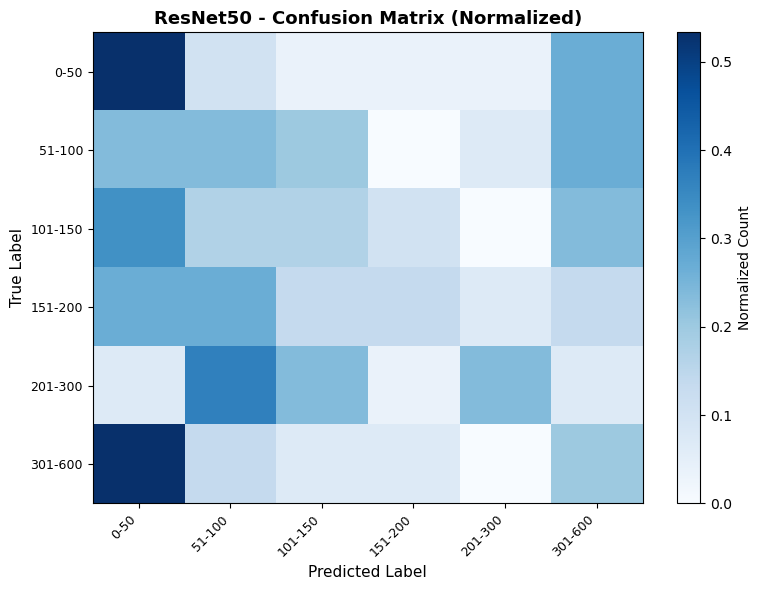

Confusion matrix saved as 'resnet50_confusion_matrix.png'


In [20]:
# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

im = ax.imshow(cm_normalized, cmap='Blues', aspect='auto')
ax.set_title(f'{CONFIG["model_name"]} - Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(class_names, fontsize=9)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Normalized Count', fontsize=10)

plt.tight_layout()
plt.savefig('resnet50_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'resnet50_confusion_matrix.png'")

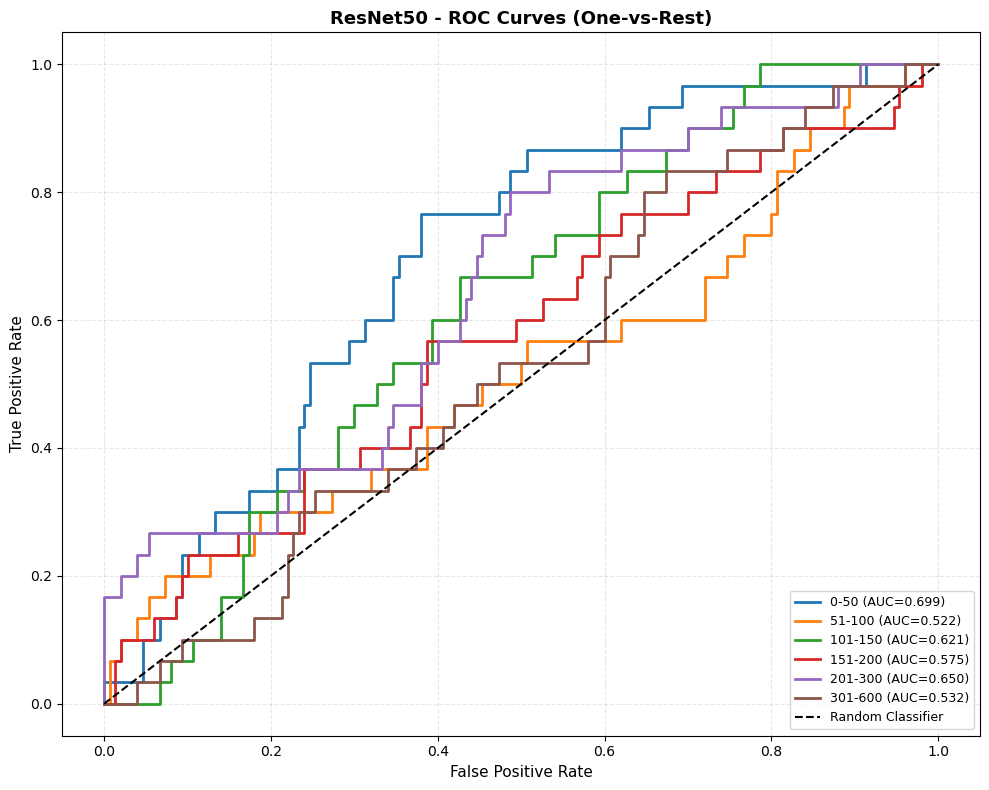

ROC curves saved as 'resnet50_roc_curves.png'


In [21]:
# Plot ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

for class_idx in range(num_classes):
    y_true_binary = (y_true == class_idx).astype(int)
    y_probs_class = y_probs[:, class_idx]
    
    fpr, tpr, _ = roc_curve(y_true_binary, y_probs_class)
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, label=f'{class_names[class_idx]} (AUC={roc_auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1.5)
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title(f'{CONFIG["model_name"]} - ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('resnet50_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("ROC curves saved as 'resnet50_roc_curves.png'")

In [22]:
# Save Results
results = {
    'model': CONFIG['model_name'],
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1': float(f1),
    'auc': float(auc_score),
    'train_time': float(train_time),
    'test_time': float(test_time),
    'epochs': CONFIG['epochs'],
    'batch_size': CONFIG['batch_size'],
    'learning_rate': CONFIG['learning_rate'],
    'class_accuracy': {class_names[i]: float(class_accuracy[i]) for i in range(num_classes)},
    'confusion_matrix': cm.tolist()
}

# Save to JSON
with open('resnet50_results.json', 'w') as f:
    json.dump(results, f, indent=4)
print("Results saved to 'resnet50_results.json'")

# Save confusion matrix to CSV
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv('resnet50_confusion_matrix.csv')
print("Confusion matrix saved to 'resnet50_confusion_matrix.csv'")

Results saved to 'resnet50_results.json'
Confusion matrix saved to 'resnet50_confusion_matrix.csv'
